In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


df = pd.read_csv("../dataset/hopitaux.csv", sep="\t", header=None)
df.columns = ["t", "id1", "id2", "role1", "role2"]
df["duration"] = 20
df.head()


# Dictionnaire id → rôle
roles = {}

for _, row in df.iterrows():
    roles[row["id1"]] = row["role1"]
    roles[row["id2"]] = row["role2"]

# Comptage par rôle
from collections import Counter
counts = Counter(roles.values())

print(counts)


Counter({'PAT': 29, 'NUR': 27, 'MED': 11, 'ADM': 8})


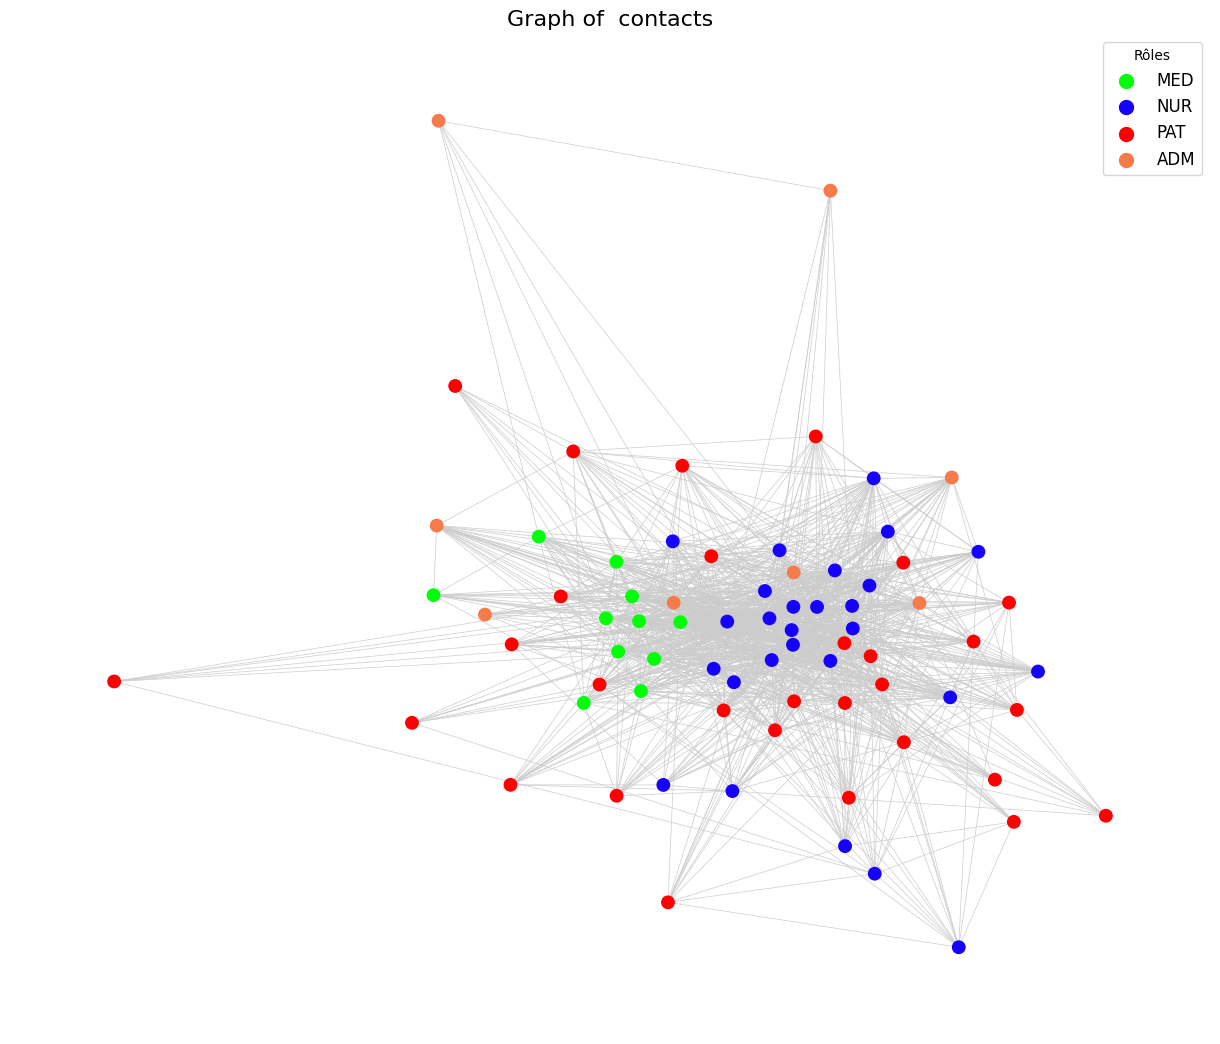

In [69]:
# representation of the graph 
G = nx.Graph()

# Définir les couleurs pour chaque rôle
role_colors = {
    'MED': "#00FF08",  
    'NUR': "#1500FF", 
    'PAT': "#FF0000",  
    'ADM': "#F57B4B"   
}
nodes_info = {}
for _, row in df.iterrows():
    if row['id1'] not in nodes_info:
        nodes_info[row['id1']] = row['role1']
    if row['id2'] not in nodes_info:
        nodes_info[row['id2']] = row['role2']

for node_id, role in nodes_info.items():
    G.add_node(node_id, role=role)

# Ajouter les arêtes avec le poids (nombre de contacts)
edge_weights = {}
for _, row in df.iterrows():
    edge = tuple(sorted([row['id1'], row['id2']]))
    edge_weights[edge] = edge_weights.get(edge, 0) + 1

for edge, weight in edge_weights.items():
    G.add_edge(edge[0], edge[1], weight=weight)

G.number_of_nodes(), G.number_of_edges()



# Récupérer les couleurs de chaque nœud selon leur rôle 
node_colors = []
for node in G.nodes():
    role = G.nodes[node].get("role", "PAT")  # par défaut PAT si jamais
    node_colors.append(role_colors.get(role, "#000000"))

# --- Choisir une disposition visuelle ---
pos = nx.spring_layout(G, seed=42, k=0.4)  # force layout lisible

# --- Dessiner le graphe ---
plt.figure(figsize=(12, 10))

nx.draw(
    G,
    pos,
    with_labels=False,
    node_color=node_colors,
    node_size=80,
    edge_color="#CCCCCC",
    width=0.5,
)

# Construire une légende des rôles
for role, color in role_colors.items():
    plt.scatter([], [], color=color, label=role, s=100)

plt.legend(title="Rôles", fontsize=12)
plt.title("Graph of  contacts", fontsize=16)
plt.show()

In [70]:
import networkx as nx
import pandas as pd

# Centralités de base
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)
closeness = nx.closeness_centrality(G, distance='weight')
eigenvector = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

# Strength
strength = {
    node: sum(d["weight"] for _, _, d in G.edges(node, data=True))
    for node in G.nodes()
}

# PageRank
pagerank = nx.pagerank(G, alpha=0.85, weight='weight')

# Construction du DataFrame
centrality_df = pd.DataFrame({
    "role": [G.nodes[n]["role"] for n in G.nodes()],
    "degree": [G.degree(n) for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "strength": [strength[n] for n in G.nodes()],
    "pagerank": [pagerank[n] for n in G.nodes()],
}, index=G.nodes())



hubs = centrality_df.sort_values(by="degree", ascending=False).head(10)
hubs




# Les individus ayant les degrees les plus élevés sont principalement les infirmiers (NUR) et quelques médecins (MED).
# Cela reflète la nature de leurs fonctions : les infirmiers circulent souvent entre plusieurs patients et services, et sont donc en interaction avec un grand nombre de personnes.
# Les médecins, bien que moins présents dans le top 10, occupent aussi des rôles centraux en raison de leurs tournées et consultations.






,role,degree,degree_centrality,betweenness,closeness,eigenvector,strength,pagerank
1098,ADM,61,0.824324,0.066678,0.415730,0.108361,1480,0.022035
1193,NUR,58,0.783784,0.017162,0.354067,0.180667,2236,0.032990
1164,NUR,57,0.770270,0.032107,0.359223,0.156347,2109,0.029446
1115,NUR,57,0.770270,0.010626,0.362745,0.495839,4286,0.055767
1295,NUR,56,0.756757,0.003829,0.330357,0.246423,3695,0.048364
1210,NUR,56,0.756757,0.070758,0.408840,0.486695,4077,0.051833
1109,NUR,55,0.743243,0.031685,0.362745,0.211188,1711,0.023363
1157,MED,53,0.716216,0.010095,0.377551,0.093193,2849,0.039456
1658,ADM,51,0.689189,0.053721,0.375635,0.178912,1242,0.017764
1144,MED,50,0.675676,0.017392,0.359223,0.077556,2045,0.028623


In [71]:
# super_contactors = centrality_df.sort_values(by="strength", ascending=False).head(10)
# super_contactors

top_strength = centrality_df.sort_values("strength", ascending=False).head(10)
top_strength[["role","degree","strength","betweenness","eigenvector","pagerank"]]
# Les super-contactors identifiés par la mesure de strength sont presque exclusivement des infirmiers (NUR).
# Cela s’explique par le fait que les infirmiers passent la majeure partie de leur journée en interaction directe avec les patients, souvent pendant des périodes prolongées (soins, surveillance, accompagnement).

,role,degree,strength,betweenness,eigenvector,pagerank
1115,NUR,57,4286,0.010626,0.495839,0.055767
1210,NUR,56,4077,0.070758,0.486695,0.051833
1295,NUR,56,3695,0.003829,0.246423,0.048364
1207,NUR,49,3130,0.041325,0.365385,0.041744
1157,MED,53,2849,0.010095,0.093193,0.039456
1193,NUR,58,2236,0.017162,0.180667,0.032990
1164,NUR,57,2109,0.032107,0.156347,0.029446
1221,MED,41,2075,0.038122,0.061605,0.028603
1144,MED,50,2045,0.017392,0.077556,0.028623
1149,NUR,48,1934,0.002922,0.146558,0.026522


In [72]:

bridges = centrality_df.sort_values(by="betweenness", ascending=False).head(10)
bridges

# Les individus ayant une betweenness élevée agissent comme des ponts structurels entre différentes communautés du réseau (les retirer pourrait fragmenter le réseau en plusieurs composantes.

,role,degree,degree_centrality,betweenness,closeness,eigenvector,strength,pagerank
1142,NUR,41,0.554054,0.183147,0.471338,0.011824,249,0.005480
1210,NUR,56,0.756757,0.070758,0.408840,0.486695,4077,0.051833
1098,ADM,61,0.824324,0.066678,0.415730,0.108361,1480,0.022035
1209,ADM,24,0.324324,0.055327,0.406593,0.006497,161,0.004100
1658,ADM,51,0.689189,0.053721,0.375635,0.178912,1242,0.017764
1100,NUR,28,0.378378,0.053417,0.400000,0.010052,288,0.006403
1114,NUR,45,0.608108,0.052982,0.400000,0.121969,1335,0.018508
1261,NUR,27,0.364865,0.047130,0.385417,0.005297,202,0.005188
1202,NUR,43,0.581081,0.043261,0.391534,0.034688,763,0.012245
1205,NUR,49,0.662162,0.043179,0.383420,0.069827,1105,0.017338


In [74]:
print(
    "Les résultats obtenus dans notre analyse sont cohérents "
    "avec ceux rapportés dans l’étude originale de Vanhems et al. (2013). "
    "Dans l’article, les infirmiers (NUR) et les médecins (MED) présentent :\n"
    " - le plus grand nombre de contacts (équivalent à notre mesure de degree),\n"
    " - la plus grande durée cumulée de contacts (équivalent à notre strength),\n"
    " - et constituent la majorité des super-contacteurs (6 HCWs représentant 42% des contacts avec les patients).\n\n"
    "Dans notre analyse de centralité :\n"
    " - les NUR et MED apparaissent également comme top-degree et top-strength,\n"
    " - ils présentent aussi des valeurs élevées en betweenness, eigenvector et PageRank, "
    "ce qui confirme leur rôle structurel central dans le réseau,\n"
    " - tandis que les patients (PAT) et l’administration (ADM) occupent des positions plus périphériques, "
    "en cohérence avec les matrices de contacts décrites dans l’article.\n\n"
    "Ainsi, nos résultats étendent ceux de l’étude : "
    "alors que les auteurs identifiaient les super-contacteurs via le nombre et la durée des contacts, "
    "nous montrons que ces mêmes individus sont également centraux selon plusieurs mesures structurelles avancées, "
    "ce qui renforce l’idée qu’ils peuvent agir comme des super-spreaders potentiels."
)


Les résultats obtenus dans notre analyse sont cohérents avec ceux rapportés dans l’étude originale de Vanhems et al. (2013). Dans l’article, les infirmiers (NUR) et les médecins (MED) présentent :
 - le plus grand nombre de contacts (équivalent à notre mesure de degree),
 - la plus grande durée cumulée de contacts (équivalent à notre strength),
 - et constituent la majorité des super-contacteurs (6 HCWs représentant 42% des contacts avec les patients).

Dans notre analyse de centralité :
 - les NUR et MED apparaissent également comme top-degree et top-strength,
 - ils présentent aussi des valeurs élevées en betweenness, eigenvector et PageRank, ce qui confirme leur rôle structurel central dans le réseau,
 - tandis que les patients (PAT) et l’administration (ADM) occupent des positions plus périphériques, en cohérence avec les matrices de contacts décrites dans l’article.

Ainsi, nos résultats étendent ceux de l’étude : alors que les auteurs identifiaient les super-contacteurs via le no

In [75]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du graphe réel 
N = G.number_of_nodes()
M = G.number_of_edges()

# degré moyen du réseau réel
k_real = 2 * M / N  

# probabilité q pour G(N, q)
q = k_real / (N - 1)

print("Nombre de noeuds N:", N)
print("Nombre d’arêtes M:", M)
print("Degré moyen réel:", k_real)
print("Probabilité q du modèle ER:", q)

# Générer un graphe ER 
G_ER = nx.erdos_renyi_graph(N, q)


Nombre de noeuds N: 75
Nombre d’arêtes M: 1139
Degré moyen réel: 30.373333333333335
Probabilité q du modèle ER: 0.4104504504504505


In [76]:
# degrés réels
degrees_real = [d for _, d in G.degree()]

# degrés ER
degrees_er = [d for _, d in G_ER.degree()]

print("Degré réel min/max:", min(degrees_real), max(degrees_real))
print("Degré ER min/max:", min(degrees_er), max(degrees_er))


Degré réel min/max: 6 61
Degré ER min/max: 18 41


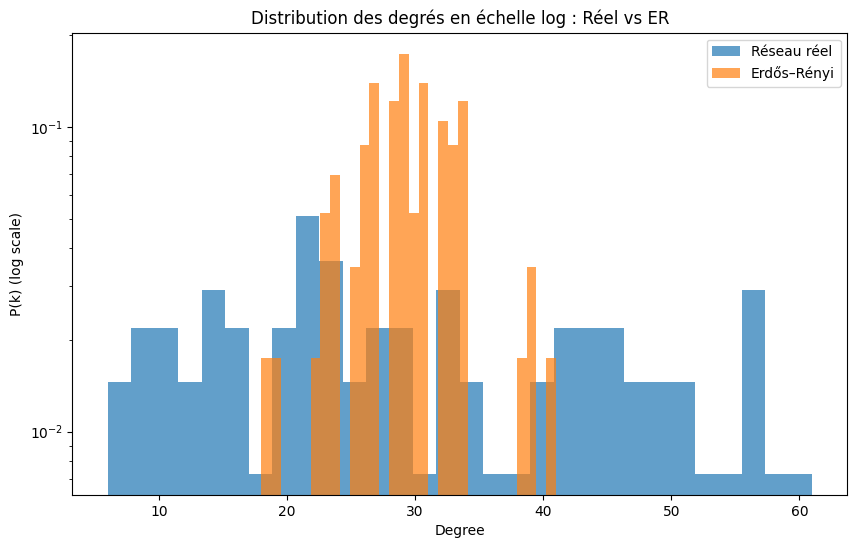

In [77]:
plt.figure(figsize=(10, 6))

# histogrammesnormalisé
plt.hist(degrees_real, bins=30, density=True, alpha=0.7, label="Réseau réel")
plt.hist(degrees_er, bins=30, density=True, alpha=0.7, label="Erdős–Rényi")

plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("P(k) (log scale)")
plt.legend()
plt.title("Distribution des degrés en échelle log : Réel vs ER")
plt.show()


In [50]:
%pip install powerlaw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 8.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Nous avons comparé la distribution des degrés de notre réseau hospitalier avec celle d’un modèle Erdős–Rényi G(N, q) de même taille et même degré moyen.

# Le réseau aléatoire présente une distribution étroite autour de la moyenne, caractéristique d’une loi de Poisson : tous les nœuds ont un degré similaire et aucun n’a un degré exceptionnellement élevé.

# En revanche, le réseau réel présente une distribution beaucoup plus hétérogène, avec des nœuds très fortement connectés (jusqu’à 61 voisins), révélant la présence de hubs et de super-contacteurs.


# ER ne capture rien de la structure sociale réelle Parmi les modèles du cours, le plus pertinent pour analyser le réseau hospitalier SocioPatterns est le Configuration Model.
# Il permet de vérifier si les propriétés observées (clustering, communautés, super-contactors) peuvent être expliquées uniquement par la distribution des degrés.
# Le modèle ER reste un point de comparaison intéressant mais trop simple, tandis que l’analyse par motifs n’est pas adaptée à ce réseau non dirigé et n’est pas utilisée dans la littérature associée.

In [79]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Degré du graphe réel
nodes_real = list(G.nodes())   # IMPORTANT : ordre des noeuds réels
degree_sequence = [d for _, d in G.degree()]

# 2. Génération du Configuration Model (MultiGraph)
G_conf = nx.configuration_model(degree_sequence)

# 3. Conversion en Graph simple
G_conf = nx.Graph(G_conf)
G_conf.remove_edges_from(nx.selfloop_edges(G_conf))

# 4. Réassigner les roles correctement
for idx, n in enumerate(G_conf.nodes()):
    real_node = nodes_real[idx]             # mapping index → vrai nœud
    G_conf.nodes[n]["role"] = G.nodes[real_node]["role"]


In [80]:
clust_real = nx.average_clustering(G)
clust_conf = nx.average_clustering(G_conf)

print("Clustering réel :", clust_real)
print("Clustering Configuration Model :", clust_conf)


Clustering réel : 0.6402796539914467
Clustering Configuration Model : 0.4086392187886524


In [81]:
import networkx as nx

# Trouver la composante géante du réseau réel
components_real = list(nx.connected_components(G))
GC_real_nodes = max(components_real, key=len)
G_real_gc = G.subgraph(GC_real_nodes).copy()

# Trouver la composante géante du Configuration Model
components_conf = list(nx.connected_components(G_conf))
GC_conf_nodes = max(components_conf, key=len)
G_conf_gc = G_conf.subgraph(GC_conf_nodes).copy()

# Calcul des distances moyennes
dist_real = nx.average_shortest_path_length(G_real_gc)
dist_conf = nx.average_shortest_path_length(G_conf_gc)

print("Distance moyenne (réseau réel) :", dist_real)
print("Distance moyenne (Configuration Model) :", dist_conf)


Distance moyenne (réseau réel) : 1.597837837837838
Distance moyenne (Configuration Model) : 1.7059459459459458


In [83]:
role_assort_real = nx.attribute_assortativity_coefficient(G, "role")
role_assort_conf = nx.attribute_assortativity_coefficient(G_conf, "role")

print("Assortativité par rôle (réseau réel) :", role_assort_real)
print("Assortativité par rôle (Configuration Model) :", role_assort_conf)


Assortativité par rôle (réseau réel) : -0.12138491200721999
Assortativité par rôle (Configuration Model) : -0.019836530414930078


In [84]:
print(
"Comparaison du réseau réel avec le Configuration Model\n"
"\n"
"Pour déterminer si les propriétés du réseau hospitalier pouvaient être expliquées "
"uniquement par la distribution des degrés, nous avons généré un réseau aléatoire via "
"le Configuration Model, qui conserve exactement le degré de chaque nœud tout en "
"randomisant les connexions.\n"
"\n"
"Les résultats mettent en évidence des différences majeures entre le réseau réel et "
"le modèle aléatoire. Le clustering est nettement plus élevé dans le réseau réel "
"(0.64 contre 0.40 pour le CM), ce qui révèle une forte cohésion locale due aux "
"équipes de soins, aux unités hospitalières et aux interactions répétées entre "
"infirmiers et patients.\n"
"\n"
"La distance moyenne est également plus faible dans le réseau réel (1.60 contre 1.71 "
"pour le CM), ce qui indique un effet small-world renforcé par la présence de "
"super-contacteurs (infirmiers et médecins) jouant un rôle de hubs et facilitant la "
"circulation de l’information ou de pathogènes.\n"
"\n"
"L’assortativité par rôle confirme cette structure non aléatoire : le réseau réel "
"présente une désassortativité marquée (r = –0.12), montrant que les interactions "
"NUR–PAT et MED–PAT dominent largement, tandis que les contacts entre individus du "
"même rôle sont rares. Ce comportement est parfaitement cohérent avec les résultats "
"de Vanhems et al. (2013). À l’inverse, le Configuration Model présente une "
"assortativité quasi nulle (r ≈ –0.02), caractéristique d’un réseau dépourvu de "
"structuration sociale.\n"
"\n"
"Dans l’ensemble, ces analyses montrent clairement que la structure du réseau "
"hospitalier ne peut pas être expliquée uniquement par la distribution des degrés. "
"L’organisation professionnelle et sociale génère des patterns non aléatoires "
"(clustering élevé, distances réduites, hubs prononcés, interactions NUR–PAT–MED) "
"qui disparaissent totalement dans le réseau aléatoire correspondant. Ces propriétés "
"structurelles constituent donc une caractéristique essentielle du réseau réel."
)


Comparaison du réseau réel avec le Configuration Model

Pour déterminer si les propriétés du réseau hospitalier pouvaient être expliquées uniquement par la distribution des degrés, nous avons généré un réseau aléatoire via le Configuration Model, qui conserve exactement le degré de chaque nœud tout en randomisant les connexions.

Les résultats mettent en évidence des différences majeures entre le réseau réel et le modèle aléatoire. Le clustering est nettement plus élevé dans le réseau réel (0.64 contre 0.40 pour le CM), ce qui révèle une forte cohésion locale due aux équipes de soins, aux unités hospitalières et aux interactions répétées entre infirmiers et patients.

La distance moyenne est également plus faible dans le réseau réel (1.60 contre 1.71 pour le CM), ce qui indique un effet small-world renforcé par la présence de super-contacteurs (infirmiers et médecins) jouant un rôle de hubs et facilitant la circulation de l’information ou de pathogènes.

L’assortativité par rôle confir